In [41]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as pyfits
import h5py
from tqdm import tqdm

from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.Data.psf import PSF
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.PointSource.point_source import PointSource
import lenstronomy.Util.simulation_util as sim_util
from lenstronomy.Util import kernel_util
import lenstronomy.Util.util as util

In [2]:
data_image_set = np.load("sim_image_noisy_set.npy")

pb_sim = pyfits.getdata("..//fits//sim_noise1.pb.fits")
pb_sim = pb_sim[0][0]
pb_sim = np.nan_to_num(pb_sim)

psf_sim = pyfits.getdata("..//fits//sim_noise1.psf.fits")
psf_sim = psf_sim[0][0]
psf_sim=np.nan_to_num(psf_sim)

In [3]:
pb_cut = pb_sim[50:150, 50:150] * 0.9  # use a pb of values smaller than 1 to test the pb implementation
psf_pixel = psf_sim[150:351,150:351]

In [4]:
background_rms = 1e-4
exp_time = np.inf  #  exposure time (arbitrary units, flux per pixel is in units #photons/exp_time unit)
numPix = 100  #  cutout pixel size
deltaPix = 0.035  #  pixel size in arcsec (area per pixel = deltaPix**2)
psf_type = 'PIXEL'  # 'gaussian', 'pixel', 'NONE'
kernel_size = 201  # PSF kernel size (odd number required).

# generate the coordinate grid and image properties
kwargs_data = sim_util.data_configure_simple(numPix, deltaPix, exp_time, background_rms)
kwargs_data['ra_at_xy_0'] = -(50)*deltaPix
kwargs_data['dec_at_xy_0'] = -(50)*deltaPix
kwargs_data['antenna_primary_beam'] = pb_cut
kwargs_data['likelihood_method'] = 'interferometry_natwt'

# generate the psf variables
kernel_cut = kernel_util.cut_psf(psf_pixel, kernel_size, normalisation=False)
kwargs_psf = {'psf_type': psf_type, 'pixel_size': deltaPix,
                    'kernel_point_source': kernel_cut, 'kernel_point_source_normalisation': False}
psf_class = PSF(**kwargs_psf)
data_class = ImageData(**kwargs_data)

kwargs_numerics = {'supersampling_convolution': False}

C:\Users\ZN\AppData\Roaming\Python\Python311\site-packages\lenstronomy\Data\psf.py:95: UserWarning: Input PSF model has at least one negative element, which is unphysical except for a PSF of an interferometric array.
  warnings.warn(


quantiles of the non linear parameters

In [5]:
# only consider free parameters: 'gamma_lens0', 'gamma1_lens1', 'gamma2_lens2',
# 'R_sersic_source_light0', 'n_sersic_source_light0', 'e1_source_light0', 'e2_source_light0',
# 'ra_image' of the four lensed images, 'dec_image' of the four lensed images

correct_param_indep_non_linear_lens_and_source = np.array((2.0, -0.012, -0.121, 0.1, 1.2, -0.032, 0.111))
correct_param_position_lensed_ps = np.array((0.08829772, 0.18901392, 0.64329577, -0.64758741,
                                       -0.95320663, 0.70292473, -0.09397415, 0.1202439))

In [6]:
chain_list = np.zeros((10, 30000, 15))

for sim in range(10):
    with h5py.File('fitting results//chain_fitting_quadruply_imaged_quasar_sim' + str(sim) + '.h5', 'r') as f:
        chain_mcmc = f['chain'][:]
    chain_list[sim] = chain_mcmc

In [7]:
def correct_prediction_for_100intervals(chain_single_param, param_correct):
    quantile_x = np.linspace(0,1,101)
    prediction = np.zeros((101))

    for i in range(101):
        half_bar = 0.5 * quantile_x[i]
        param_interval_temp = np.zeros((2))
        param_interval_temp = np.quantile(chain_single_param, (0.5 - half_bar, 0.5 + half_bar))
        count_on_errorbar_temp = 0
        if (param_correct > param_interval_temp[0]) and (param_correct < param_interval_temp[1]):
            count_on_errorbar_temp = 1
        prediction[i] = count_on_errorbar_temp
    return prediction

In [8]:
quantile_indep_non_linear_lens_and_source = np.zeros((101))
n_count_indep_non_linear_lens_and_source = 0
for i in tqdm(range(10)):
    for j in range(7):
    
        quantile_indep_non_linear_lens_and_source += correct_prediction_for_100intervals(
            chain_list[i,:,j], correct_param_indep_non_linear_lens_and_source[j])
        n_count_indep_non_linear_lens_and_source += 1
    
quantile_indep_non_linear_lens_and_source /= n_count_indep_non_linear_lens_and_source

100%|██████████| 10/10 [00:04<00:00,  2.09it/s]


In [9]:
quantile_lensed_position_ps = np.zeros((101))
n_count_lensed_position_ps = 0
for i in tqdm(range(10)):
    for j in range(8):
    
        quantile_lensed_position_ps += correct_prediction_for_100intervals(
            chain_list[i,:,7+j], correct_param_position_lensed_ps[j])
        n_count_lensed_position_ps += 1
    
quantile_lensed_position_ps /= n_count_lensed_position_ps

100%|██████████| 10/10 [00:05<00:00,  1.78it/s]


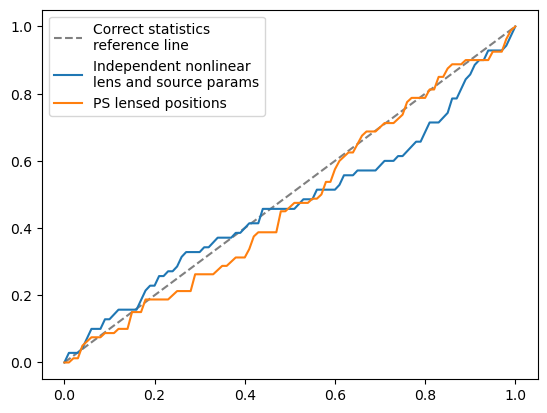

In [11]:
quantile_x = np.linspace(0,1,101)

plt.plot(quantile_x,quantile_x,'--',color='gray',label='Correct statistics\nreference line')
plt.plot(quantile_x, quantile_indep_non_linear_lens_and_source, label='Independent nonlinear\nlens and source params')
plt.plot(quantile_x, quantile_lensed_position_ps, label='PS lensed positions')
plt.legend()
plt.show()

Now we get the chain of the non-linear parameters that are solved by a non-linear solver, using the lensed PS position (so they are not free parameters during the fittings).

In [12]:
kwargs_constraints = {'joint_source_with_point_source': [[0, 0]],
                      'num_point_source_list': [4],
                      'solver_type': 'PROFILE',}

kwargs_lens_fixed = [{}, {'ra_0': 0, 'dec_0': 0}]

kwargs_model = {'lens_model_list': ['EPL', 'SHEAR'],
 'source_light_model_list': ['SERSIC_ELLIPSE'],
 'point_source_model_list': ['LENSED_POSITION'],
 'additional_images_list': [False],
 'fixed_magnification_list': [True]}

In [13]:
kwargs_lens_input = [ { "theta_E": 0.8, "gamma": 2.0, "e1": 0.355, "e2": -0.262, "center_x": -0.098, "center_y": -0.030, },
    {"gamma1": -0.012,  "gamma2": -0.121, 'ra_0': 0, 'dec_0': 0,} ]

In [14]:
from lenstronomy.Sampling.parameters import Param
# make instance of parameter class with given model options, constraints and fixed parameters #

param = Param(kwargs_model, kwargs_lens_fixed,
              kwargs_lens_init=kwargs_lens_input, **kwargs_constraints)
# the number of non-linear parameters and their names #
num_param, param_list = param.num_param()

In [15]:
param_list

['gamma_lens0',
 'gamma1_lens1',
 'gamma2_lens1',
 'R_sersic_source_light0',
 'n_sersic_source_light0',
 'e1_source_light0',
 'e2_source_light0',
 'ra_image',
 'ra_image',
 'ra_image',
 'ra_image',
 'dec_image',
 'dec_image',
 'dec_image',
 'dec_image']

In [26]:
# parameters got from non-linear param solver: 'thetaE_lens0', 'e1_lens0', 'e2_lens0', 
# 'center_x_lens0', 'center_y_lens0', 'center_x_source0', 'center_y_source0'
correct_param_solved_param_lens_and_source = np.array((0.8, 0.355, -0.262, -0.098, -0.030, -0.020, -0.095))

In [18]:
# Now we just consider a subset of N_sample samples
N_sample = 1000

In [33]:
#use kwargs_result = param.args2kwargs(chain_list[0,0])
chain_list_solved_non_linear = np.zeros((10, N_sample, 7))
for i in tqdm(range(10)):
    for j in range(N_sample):
        kwargs_result = param.args2kwargs(chain_list[i, 20000+j])
        chain_list_solved_non_linear[i,j,0] = kwargs_result['kwargs_lens'][0]['theta_E']
        chain_list_solved_non_linear[i,j,1] = kwargs_result['kwargs_lens'][0]['e1']
        chain_list_solved_non_linear[i,j,2] = kwargs_result['kwargs_lens'][0]['e2']
        chain_list_solved_non_linear[i,j,3] = kwargs_result['kwargs_lens'][0]['center_x']
        chain_list_solved_non_linear[i,j,4] = kwargs_result['kwargs_lens'][0]['center_y']
        chain_list_solved_non_linear[i,j,5] = kwargs_result['kwargs_source'][0]['center_y']
        chain_list_solved_non_linear[i,j,6] = kwargs_result['kwargs_source'][0]['center_y']

100%|██████████| 10/10 [00:48<00:00,  4.85s/it]


In [34]:
quantile_solved_non_linear_lens_and_source = np.zeros((101))
n_count_solved_non_linear_lens_and_source = 0
for i in tqdm(range(10)):
    for j in range(7):
    
        quantile_solved_non_linear_lens_and_source += correct_prediction_for_100intervals(
            chain_list_solved_non_linear[i,:,j], correct_param_solved_param_lens_and_source[j])
        n_count_solved_non_linear_lens_and_source += 1
    
quantile_solved_non_linear_lens_and_source /= n_count_solved_non_linear_lens_and_source

100%|██████████| 10/10 [00:00<00:00, 12.33it/s]


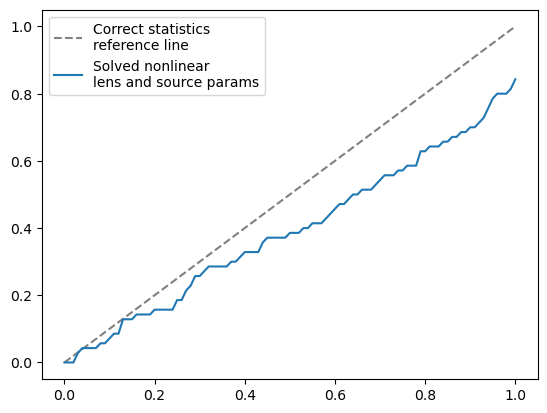

In [35]:
quantile_x = np.linspace(0,1,101)

plt.plot(quantile_x, quantile_x,'--',color='gray',label='Correct statistics\nreference line')
plt.plot(quantile_x, quantile_solved_non_linear_lens_and_source, label='Solved nonlinear\nlens and source params')
plt.legend()
plt.show()

Now we use the chain of the independent linear parameters and solved nonlinear parameters to solve for the amps of the sersic and point source

- Note that the 1sigma error bars of amplitudes are **not** estimated by linear solving the amplitude of each sample and taking the quantile.
- Instead, we treat each sample point as an independent gaussian likelihood function of the amplitudes, and compute the average and uncertainty using
$$\mu = \frac{1}{N_{sample}}\sum \mu_i$$
$$\sigma^2 = \frac{1}{N_{sample}}\sum(\sigma^2_i+\mu_i^2) - \mu^2$$
where $i$ stands for the sample index.
- $\mu_i$ is the average amplitude for each sample, and is the `params_coefficient` output of the linear solver.
- $\sigma_i^2$ is the variance of the amplitude for each sample, and is the diagonal entries of the `param_cov` output of the linear solver.

In [38]:
from lenstronomy.ImSim.image_linear_solve import ImageLinearFit

In [39]:
from scipy.stats import norm
def sigma_from_percentile(p):
    return norm.ppf((1 + p) / 2)

In [43]:
lens_model_list = ["EPL", "SHEAR"]
lens_model_class = LensModel(lens_model_list=lens_model_list)

source_model_list = ["SERSIC_ELLIPSE"]
source_model_class = LightModel(light_model_list=source_model_list)

point_source_list = ['LENSED_POSITION']
point_source_class = PointSource(point_source_type_list=point_source_list, fixed_magnification_list=[True])

In [44]:
amp_sigma = np.zeros((10, 2))
amp_average = np.zeros((10, 2))

In [53]:
for sim in tqdm(range(10)):
    data_class.update_data(data_image_set[sim])
    imageLinearFit = ImageLinearFit(data_class, psf_class, lens_model_class, source_model_class,
                                    point_source_class=point_source_class)
    for i in range(N_sample):
        kwargs_result = param.args2kwargs(chain_list[sim, 20000+i])
        _, _, param_cov, params_coefficient = imageLinearFit.image_linear_solve(
            kwargs_lens = kwargs_result['kwargs_lens'],
            kwargs_source = kwargs_result['kwargs_source'],
            kwargs_ps = kwargs_result['kwargs_ps'], 
            inv_bool=True)

        amp_average[sim,0] += params_coefficient[0]
        amp_average[sim,1] += params_coefficient[1]
        
        amp_sigma[sim,0] += param_cov[0,0] + params_coefficient[0]**2
        amp_sigma[sim,1] += param_cov[1,1] + params_coefficient[1]**2

    amp_average[sim,0] /= N_sample
    amp_average[sim,1] /= N_sample
    
    amp_sigma[sim,0] = amp_sigma[sim,0] / N_sample - amp_average[sim,0]**2
    amp_sigma[sim,1] = amp_sigma[sim,1] / N_sample - amp_average[sim,1]**2
    
    amp_sigma[sim,0] = np.sqrt(amp_sigma[sim,0])
    amp_sigma[sim,1] = np.sqrt(amp_sigma[sim,1])

100%|██████████| 10/10 [04:37<00:00, 27.74s/it]


In [66]:
quantile_x = np.linspace(0,1,101)

quantile_amp_sersic_mixed_likelihood = np.zeros((101))
for j in range(101):
    k = sigma_from_percentile(quantile_x[j])
    prediction = 0
    for sim in range(10):
        if (amp_average[sim,0] - k * amp_sigma[sim,0] < 0.03) and (amp_average[sim,0] + k * amp_sigma[sim,0] > 0.03):
            prediction += 1
    quantile_amp_sersic_mixed_likelihood[j] = prediction / 10

quantile_amp_ps_mixed_likelihood = np.zeros((101))
for j in range(101):
    k = sigma_from_percentile(quantile_x[j])
    prediction = 0
    for sim in range(10):
        if (amp_average[sim,1] - k * amp_sigma[sim,1] < 0.002) and (amp_average[sim,1] + k * amp_sigma[sim,1] > 0.002):
            prediction += 1
    quantile_amp_ps_mixed_likelihood[j] = prediction / 10

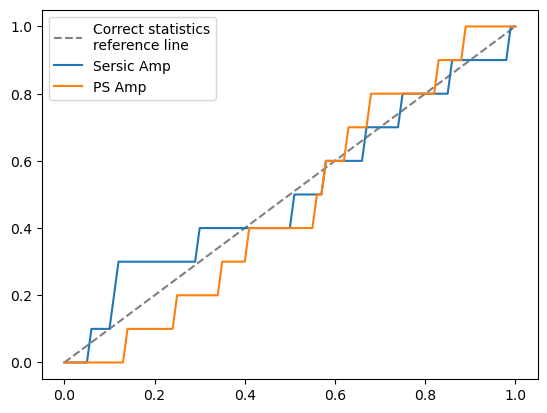

In [67]:
quantile_x = np.linspace(0,1,101)

plt.plot(quantile_x, quantile_x,'--',color='gray',label='Correct statistics\nreference line')
plt.plot(quantile_x, quantile_amp_sersic_mixed_likelihood, label='Sersic Amp')
plt.plot(quantile_x, quantile_amp_ps_mixed_likelihood, label='PS Amp')
plt.legend()
plt.show()

C:\Users\ZN\AppData\Local\Temp\ipykernel_15752\1967139646.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels([f'{x:.0%}' for x in plt.gca().get_yticks()])
C:\Users\ZN\AppData\Local\Temp\ipykernel_15752\1967139646.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([f'{x:.0%}' for x in plt.gca().get_xticks()])


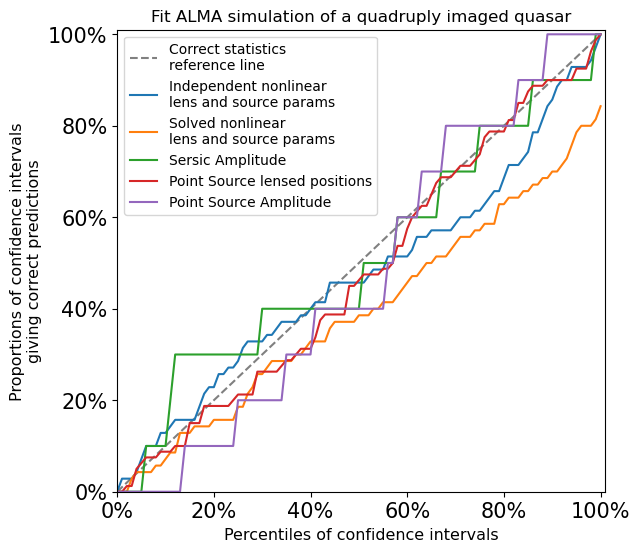

In [75]:
quantile_x = np.linspace(0,1,101)

fig = plt.figure(figsize=(6.3,6))
plt.plot(quantile_x, quantile_x,'--',color='gray',label='Correct statistics\nreference line')
plt.plot(quantile_x, quantile_indep_non_linear_lens_and_source, label='Independent nonlinear\nlens and source params')
plt.plot(quantile_x, quantile_solved_non_linear_lens_and_source, label='Solved nonlinear\nlens and source params')
plt.plot(quantile_x, quantile_amp_sersic_mixed_likelihood, label='Sersic Amplitude')
plt.plot(quantile_x, quantile_lensed_position_ps, label='Point Source lensed positions')
plt.plot(quantile_x, quantile_amp_ps_mixed_likelihood, label='Point Source Amplitude')
plt.xlim([0, 1.01])
plt.ylim([0, 1.01])
plt.gca().set_yticklabels([f'{x:.0%}' for x in plt.gca().get_yticks()]) 
plt.gca().set_xticklabels([f'{x:.0%}' for x in plt.gca().get_xticks()]) 
plt.tick_params(axis='both', which='major', labelsize=15)

plt.title("Fit ALMA simulation of a quadruply imaged quasar")
plt.ylabel("Proportions of confidence intervals\ngiving correct predictions", fontsize = 11.5)
plt.xlabel("Percentiles of confidence intervals", fontsize = 11.5)
plt.legend()

plt.show()